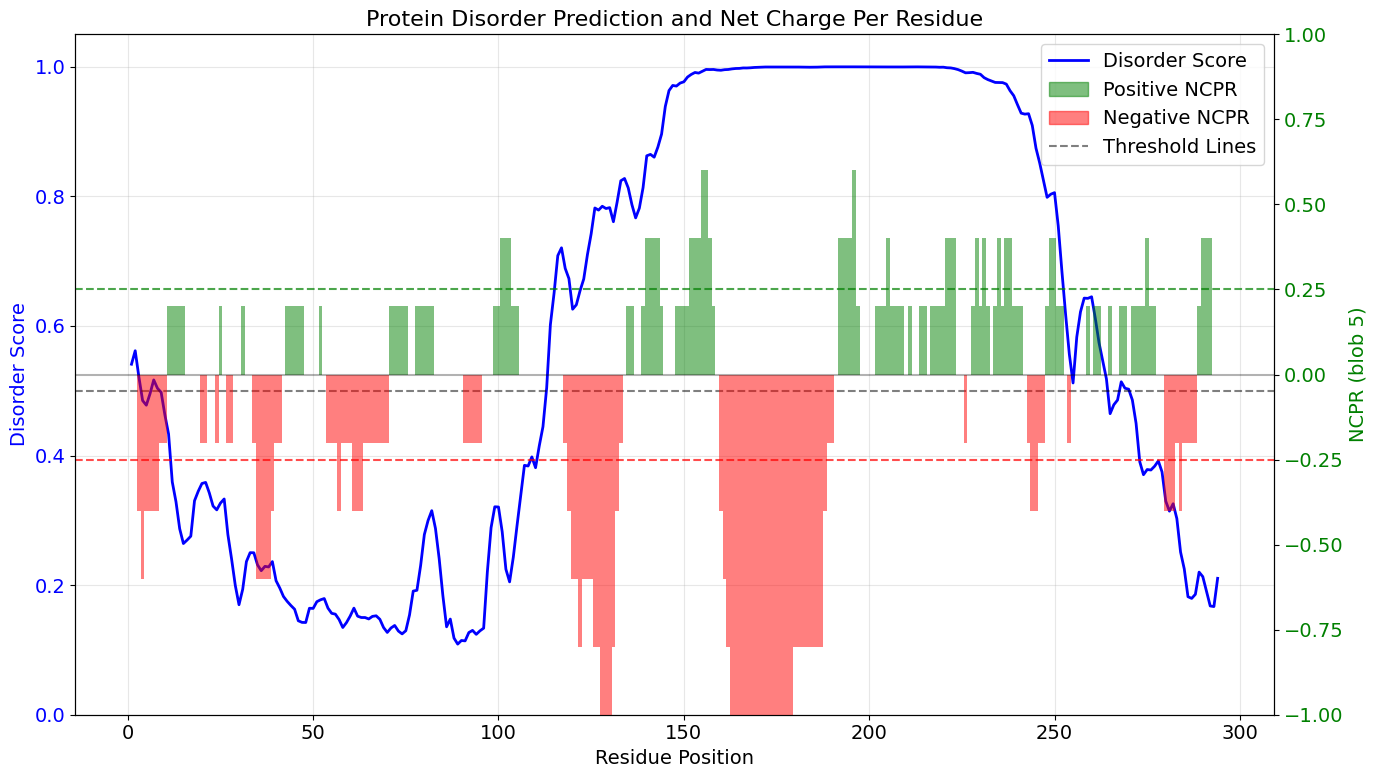

In [34]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import localcider
from localcider.sequenceParameters import SequenceParameters

# Add AIUPred directory to path
sys.path.append('/home/ilnitsky/tools/AIUPred')
import aiupred_lib

# Define the protein sequence
sequence = "MEDSMDMDMSPLRPQNYLFGCELKADKDYHFKVDNDENEHQLSLRTVSLGAGAKDELHIVEAEAMNYEGSPIKVTLATLKMSVQPTVSLGGFEITPPVVLRLKCGSGPVHISGQHLVAVEEDAESEDEEEEDVKLLSISGKRSAPGGGSKVPQKKVKLAAEEDDEDDDDDDDDDEDDDDDDFDDEETEEKAPVKKSIRDTPAKNAQKSNQNGKDSKPSTPRSKGQESFKKQEKTPKTPKGPTSVEDIKAKMQASIEKGGSLPKVEAKFINYVKNCFRMTDQEAIQDLWQWRKSL"

# Get predictions and data
# AIUpred disorder prediction
disorder_prediction = aiupred_lib.aiupred_disorder(sequence)
positions = range(1, len(sequence) + 1)

# LocalCIDER NCPR data
SeqOb = SequenceParameters(sequence)
ncpr_data = SeqOb.get_linear_NCPR(blobLen=5)
ncpr_x = ncpr_data[0, :]
ncpr_y = ncpr_data[1, :]

# Create a single figure with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# Plot AIUPred disorder prediction (line)
disorder_line = ax1.plot(positions, disorder_prediction, 'b-', linewidth=2, label='Disorder Score')
ax1.set_ylabel('Disorder Score', fontsize=14, color='blue')
ax1.set_xlabel('Residue Position', fontsize=14)
ax1.set_title('Protein Disorder Prediction and Net Charge Per Residue', fontsize=16)
ax1.set_ylim([0, 1.05])
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Horizontal line at disorder threshold (0.5)
ax1.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label='Disorder Threshold (0.5)')

# Create the bars for NCPR
bars = []
for i in range(len(ncpr_x)):
    if ncpr_y[i] >= 0:
        bar = ax2.bar(ncpr_x[i], ncpr_y[i], width=1, color='green', alpha=0.5, align='center')
    else:
        bar = ax2.bar(ncpr_x[i], ncpr_y[i], width=1, color='red', alpha=0.5, align='center')
    bars.append(bar)

# Set NCPR axis properties
ax2.set_ylabel('NCPR (blob 5)', fontsize=14, color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_ylim([-1.0, 1.0])

# Add NCPR threshold lines - align the y=0 line with the disorder threshold line at y=0.5
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3, label='NCPR 0.0')
ax2.axhline(y=0.25, color='green', linestyle='--', alpha=0.7, label='NCPR 0.25')
ax2.axhline(y=-0.25, color='red', linestyle='--', alpha=0.7, label='NCPR -0.25')

# Add legend for both plots
blue_patch = plt.Line2D([0], [0], color='blue', linewidth=2, label='Disorder Score')
green_patch = plt.Rectangle((0,0), 1, 1, color='green', alpha=0.5, label='Positive NCPR')
red_patch = plt.Rectangle((0,0), 1, 1, color='red', alpha=0.5, label='Negative NCPR')
thresh_line = plt.Line2D([0], [0], color='k', linestyle='--', alpha=0.5, label='Threshold Lines')

# Combine legends
legend_elements = [blue_patch, green_patch, red_patch, thresh_line]
ax1.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# To save the combined plot
# plt.savefig('/home/ilnitsky/NPM/combined_plot.png', dpi=300)


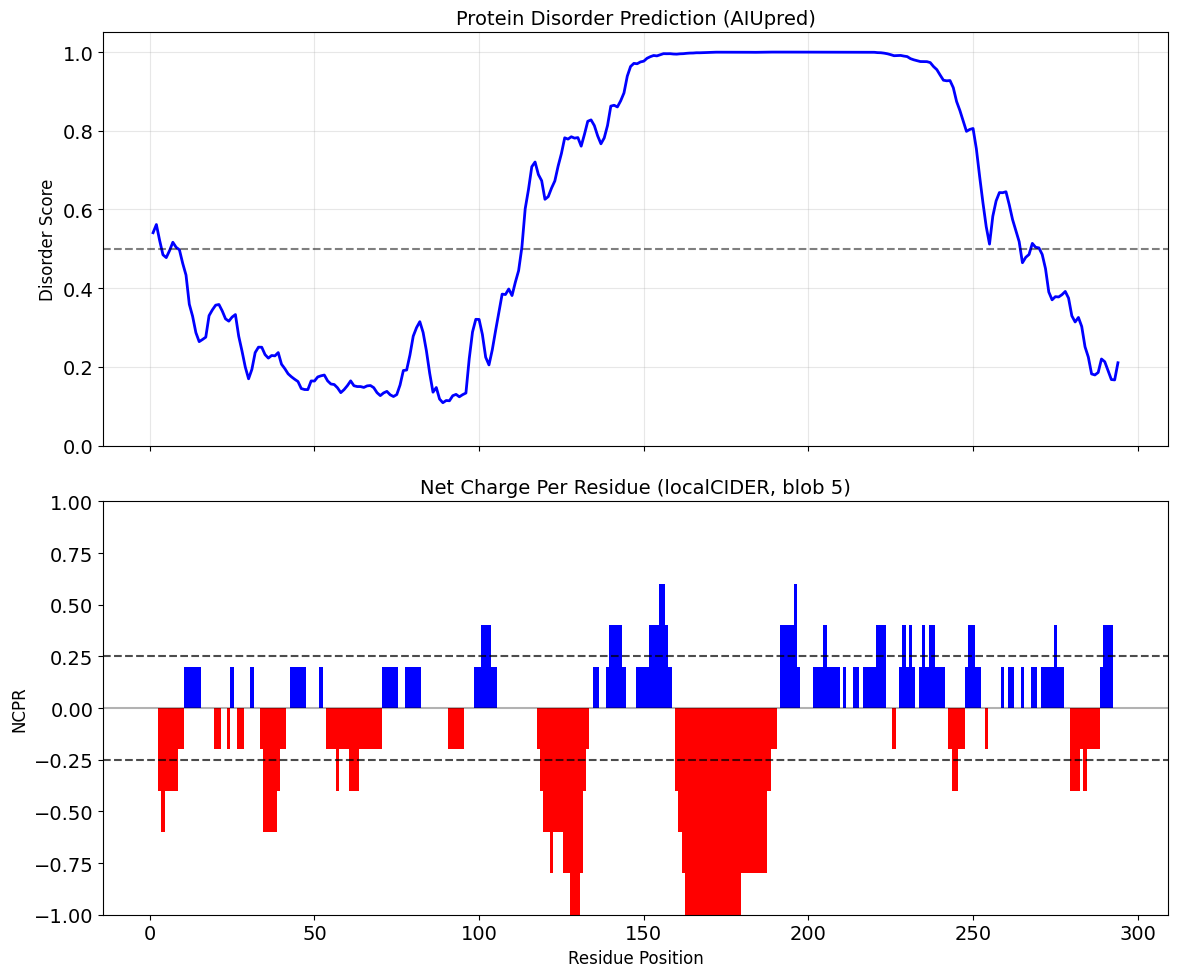

In [33]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import localcider
from localcider.sequenceParameters import SequenceParameters

# Add AIUPred directory to path
sys.path.append('/home/ilnitsky/tools/AIUPred')
import aiupred_lib

# Define the protein sequence
sequence = "MEDSMDMDMSPLRPQNYLFGCELKADKDYHFKVDNDENEHQLSLRTVSLGAGAKDELHIVEAEAMNYEGSPIKVTLATLKMSVQPTVSLGGFEITPPVVLRLKCGSGPVHISGQHLVAVEEDAESEDEEEEDVKLLSISGKRSAPGGGSKVPQKKVKLAAEEDDEDDDDDDDDDEDDDDDDFDDEETEEKAPVKKSIRDTPAKNAQKSNQNGKDSKPSTPRSKGQESFKKQEKTPKTPKGPTSVEDIKAKMQASIEKGGSLPKVEAKFINYVKNCFRMTDQEAIQDLWQWRKSL"

# For localCIDER, use similar sequence but check for any differences
cider_sequence = "MEDSMDMDMSPLRPQNYLFGCELKADKDYHFKVDNDENEHQLSLRTVSLGAGAKDELHIVEAEAMNYEGSPIKVTLATLKMSVQPTVSLGGFEITPPVVLRLKCGSGPVHISGQHLVAVEEDAESEDEEEEDVKLLSISGKRSAPGGGSKVPQKKVKLAAEEDDEDDDDDDDDDEDDDDDDFDDEETEEKAPVKKSIRDTPAKNAQKSNQNGKDSKPSTPRSKGQESFKKQEKTPKTPKGPTSVEDIKAKMQASIEKGGSLPKVEAKFINYVKNCFRMTDQEAIQDLWQWRKSL"

# Get predictions and data
# AIUpred disorder prediction
disorder_prediction = aiupred_lib.aiupred_disorder(sequence)
positions = range(1, len(sequence) + 1)

# LocalCIDER NCPR data
SeqOb = SequenceParameters(cider_sequence)
ncpr_data = SeqOb.get_linear_NCPR(blobLen=5)
ncpr_x = ncpr_data[0, :]
ncpr_y = ncpr_data[1, :]

# Create figure with two subplots sharing x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot AIUpred disorder on top subplot
ax1.plot(positions, disorder_prediction, 'b-', linewidth=2)
ax1.set_ylabel('Disorder Score', fontsize=12)
ax1.set_title('Protein Disorder Prediction (AIUpred)', fontsize=14)
ax1.set_ylim([0, 1.05])
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.5, color='k', linestyle='--', alpha=0.5)  # Optional threshold line

# Plot NCPR on bottom subplot
for i in range(len(ncpr_x)):
    if ncpr_y[i] >= 0:
        ax2.bar(ncpr_x[i], ncpr_y[i], width=1, color='blue', align='center')
    else:
        ax2.bar(ncpr_x[i], ncpr_y[i], width=1, color='red', align='center')

ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax2.axhline(y=0.25, color='k', linestyle='--', alpha=0.7)
ax2.axhline(y=-0.25, color='k', linestyle='--', alpha=0.7)
ax2.set_xlabel('Residue Position', fontsize=12)
ax2.set_ylabel('NCPR', fontsize=12)
ax2.set_title('Net Charge Per Residue (localCIDER, blob 5)', fontsize=14)
ax2.set_ylim([-1.0, 1.0])

plt.tight_layout()
plt.show()

# To save the combined plot
# plt.savefig('/home/ilnitsky/NPM/combined_plot.png', dpi=300)


In [ ]:
# NPM_2 environment

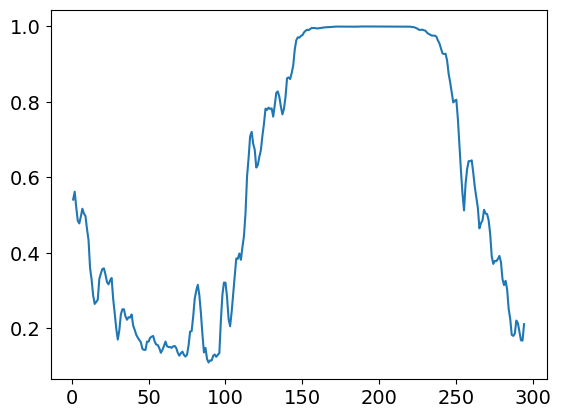

In [32]:
import sys
import matplotlib.pyplot as plt
sys.path.append('/home/ilnitsky/tools/AIUPred')
import aiupred_lib

sequence = "MEDSMDMDMSPLRPQNYLFGCELKADKDYHFKVDNDENEHQLSLRTVSLGAGAKDELHIVEAEAMNYEGSPIKVTLATLKMSVQPTVSLGGFEITPPVVLRLKCGSGPVHISGQHLVAVEEDAESEDEEEEDVKLLSISGKRSAPGGGSKVPQKKVKLAAEEDDEDDDDDDDDDEDDDDDDFDDEETEEKAPVKKSIRDTPAKNAQKSNQNGKDSKPSTPRSKGQESFKKQEKTPKTPKGPTSVEDIKAKMQASIEKGGSLPKVEAKFINYVKNCFRMTDQEAIQDLWQWRKSL"

prediction = aiupred_lib.aiupred_disorder(sequence)

positions = range(1, len(sequence) + 1)

plt.plot(positions, prediction)


findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

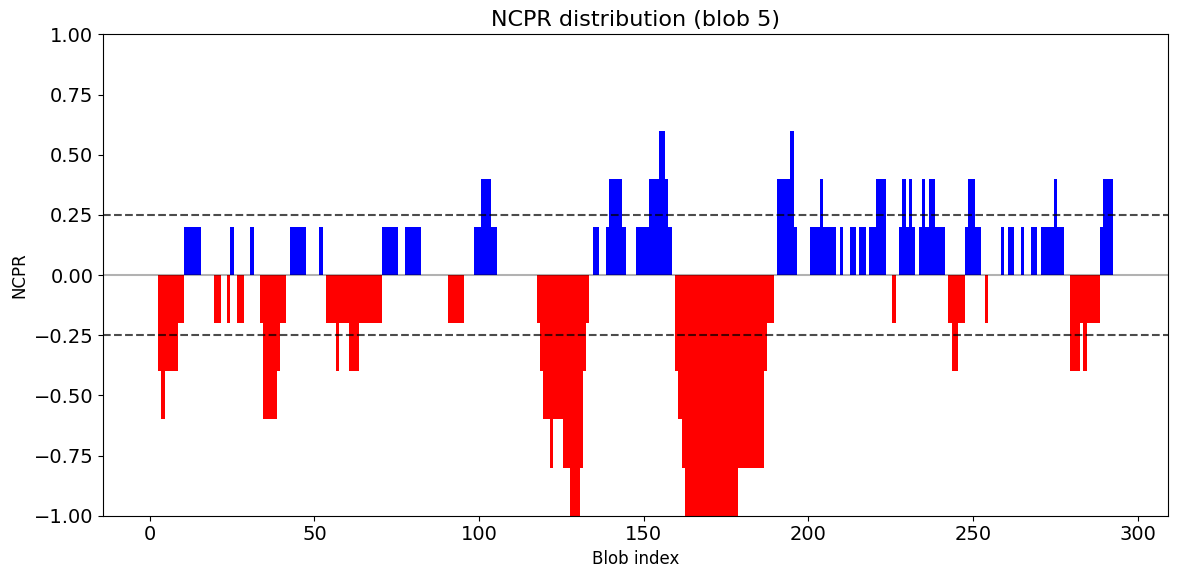

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import localcider
from localcider.sequenceParameters import SequenceParameters

# Define the protein sequence
SeqOb = SequenceParameters("MEDSMDMDMSPLRPQNYLFGCELKADKDYHFKVDNDENEHQLSLRTVSLGAGAKDELHIVEAEAMNYEGSPIKVTLATLKMSVQPTVSLGGFEITPPVVLRLKCGSGPVHISGQHLVAVEEDAESEDEEEEDVKLLSISGKRSAPGGGSKVPQKKVKLAADEDDDDDDEDDDDEDDDDDDFDDEEAEEKAPVKKSIRDTPAKNAQKSNQNGKDSKPSSTPRSKGQESFKKQEKTPKTPKGPSSVEDIKAKMQASIEKGGSLPKVEAKFINYVKNCFRMTDQEAIQDLWQWRKSL")

# Get the Net Charge Per Residue (NCPR) data with blob size 5
data = SeqOb.get_linear_NCPR(blobLen=5)

# Extract x and y values
x = data[0, :]
y = data[1, :]

# Create the plot
plt.figure(figsize=(12, 6))

# Create bar plot with different colors for positive and negative values
for i in range(len(x)):
    if y[i] >= 0:
        plt.bar(x[i], y[i], width=1, color='blue', align='center')
    else:
        plt.bar(x[i], y[i], width=1, color='red', align='center')

# Add horizontal dashed lines at thresholds
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axhline(y=0.25, color='k', linestyle='--', alpha=0.7)
plt.axhline(y=-0.25, color='k', linestyle='--', alpha=0.7)

# Update labels and title
plt.xlabel('Blob index', fontsize=12)
plt.ylabel('NCPR', fontsize=12)
plt.title('NCPR distribution (blob 5)', fontsize=16)

# Set y-axis limits to match the image
plt.ylim([-1.0, 1.0])

plt.tight_layout()
plt.show()

# You can also save the plot
# plt.savefig('ncpr_plot.png', dpi=300)

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

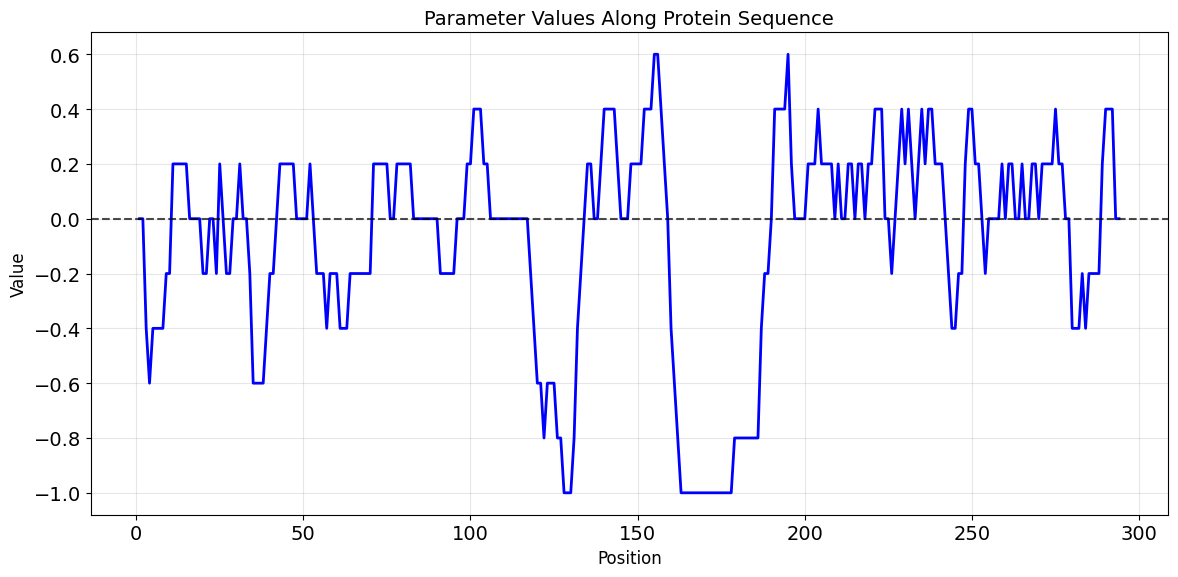